# Notebook for Processing TR-XRD Data using the TRXRD Code

## Import Necessary Packages

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import trxrd
from globals import *

%matplotlib widget

## Define File Paths

In [9]:
# Main diffraction data folder
data_path = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\detimages")

# Detector mask file
mask_file = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif")

## Import Images

125 TIFF files found in C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\detimages.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:226: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(test + 1), cmap="jet")


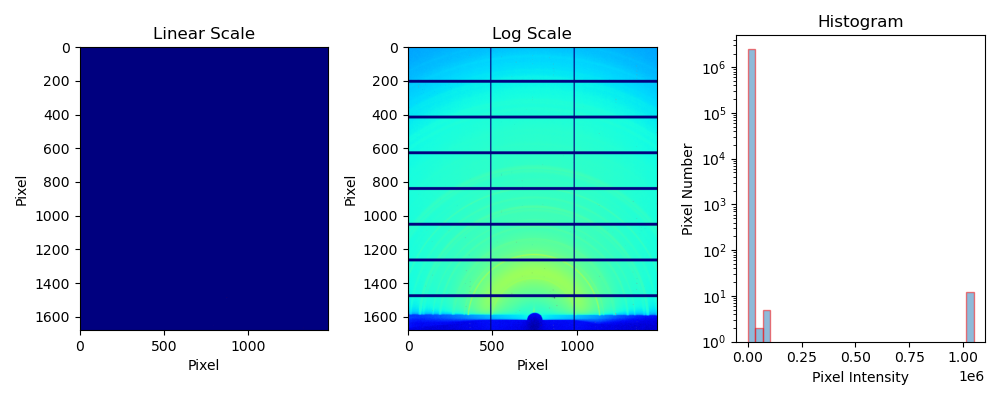

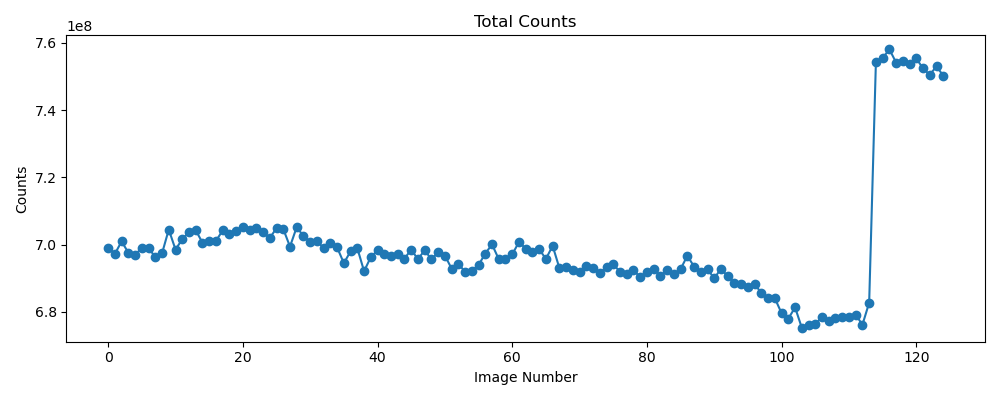

dict_keys(['images', 'sample_name', 'fluence', 'delay', 'image_number', 'counts', 'file_names'])
Images shape: (125, 1679, 1475)
Counts shape: (125,)
First few delays: [1.00e-10 9.00e-10 1.25e-10 2.00e-10 3.00e-07]


In [10]:
data_dict = trxrd.get_image_details(
    folder_path=data_path,
    sample_name=None,   # or use something like "550nm_re"
    sort=True,
    filter_data=False,
    plot=True,
)

print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)
print("First few delays:", data_dict["delay"][:5])

## Remove Images Based on Total Counts

3 images removed from 125 initial images


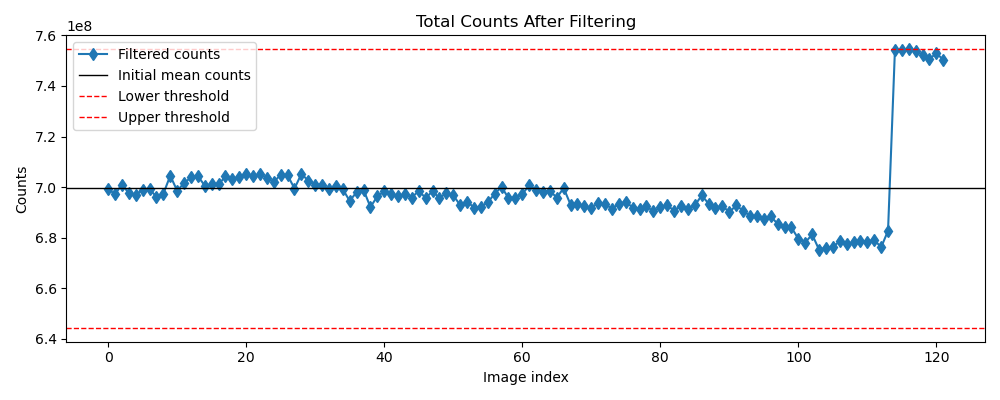

Clean images shape: (122, 1679, 1475)
Removed images: 3


In [11]:
count_result = trxrd.remove_counts(
    data_dict,
    std_factor=STD_FACTOR,
    added_range=None,   # e.g. [[10, 20]]
    plot=True,
    return_dict=True,
)

clean_dict = count_result["filtered_data"]

print("Clean images shape:", clean_dict["images"].shape)
print("Removed images:", count_result["n_removed"])

## Apply Detector Mask

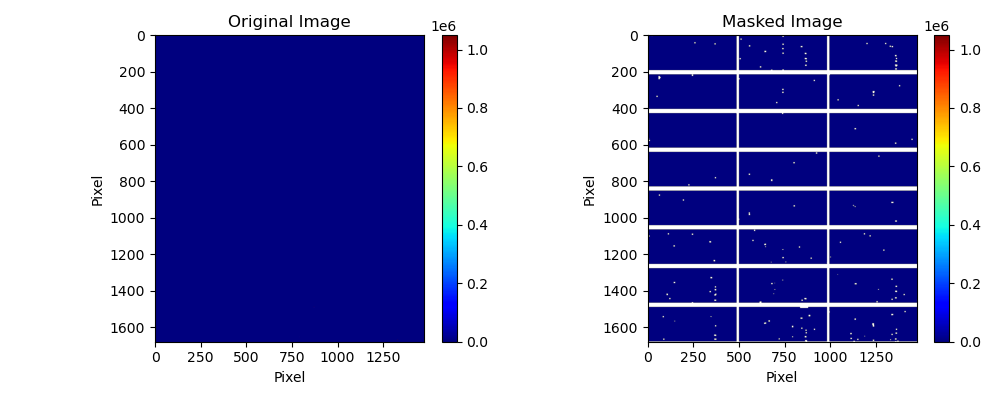

In [12]:
masked_images = trxrd.apply_nan_mask(
    clean_dict["images"],
    mask_path=mask_file,
    plot=True,
    image_index=0,
)

clean_dict["images"] = masked_images

## Remove Hot Pixels

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:1057: RuntimeWarning: Mean of empty slice
  mean_image = np.nanmean(image_stack, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Removing hot pixels from 122 image(s)...
  Completed 100/122 (82.0%)
  Completed 122/122 (100.0%)
Done removing hot pixels.


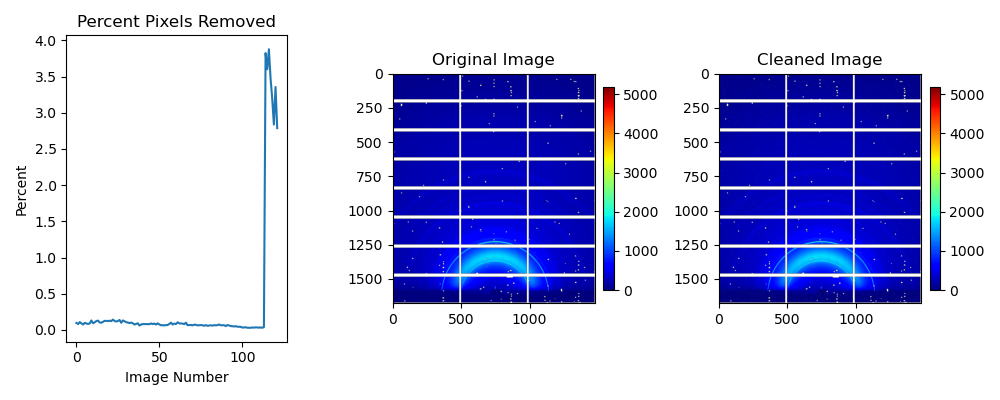

Mean percent pixels removed: 0.2931748793300236
Max percent pixels removed: 3.877570385923825


In [13]:
xr_result = trxrd.remove_xrays_pool(
    clean_dict["images"],
    std_factor=STD_FACTOR,
    plot=True,
    image_index=0,
    return_dict=True,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
)

clean_dict["images"] = xr_result["clean_data"]

print("Mean percent pixels removed:", np.nanmean(xr_result["pct_removed"]))
print("Max percent pixels removed:", np.nanmax(xr_result["pct_removed"]))

## Find Centers for Images

Finding centers for 122 images...
  Completed 100/122 (82.0%)
  Completed 122/122 (100.0%)
Done finding centers.


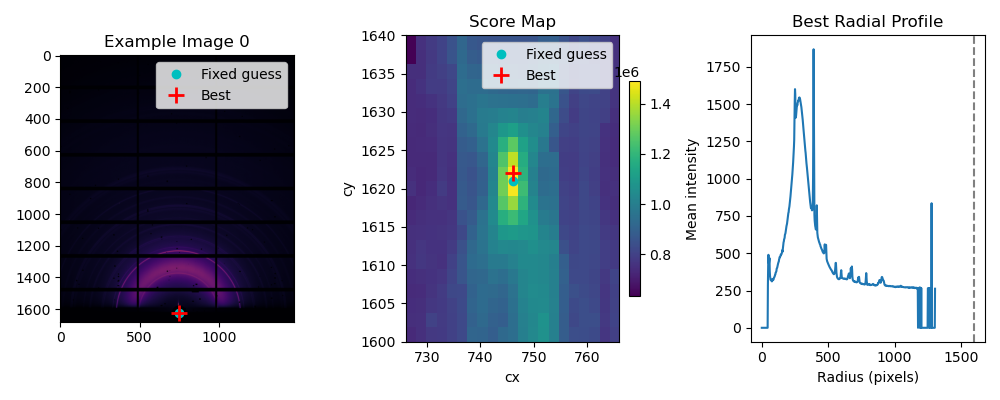

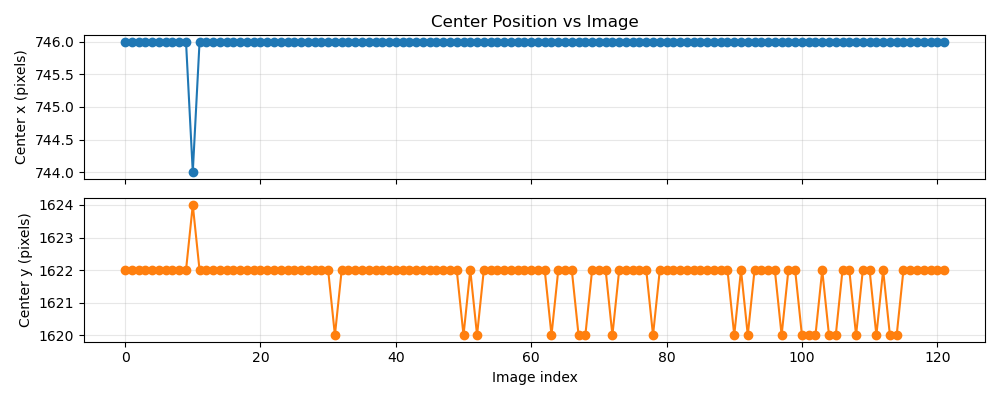

Centers shape: (122, 2)
First center: [ 746. 1622.]
[ 745.98360656 1621.68852459]


In [14]:
center_result = trxrd.find_centers_in_stack_radial_parallel(
    data_array=clean_dict["images"],
    center_guess=(CENTER_Y, CENTER_X),   # note: (y, x)
    search_radius=20,
    center_mask=None,
    r_min=0,
    r_max=1600,
    downsample=2,
    intensity_threshold=None,
    top_percentile=60,
    max_workers=MAX_PROCESSORS,
    progress_interval=100,
    plot_example=True,
    example_index=0,
    plot_center_vs_image=True,
)

centers = center_result["centers_xy"]
print("Centers shape:", centers.shape)
print("First center:", centers[0])
mean_center = np.mean(centers, axis=0)
print(mean_center)

## Compute Azimuthal Average

Integrating 122 images...
  Completed 100/122 (82.0%)
  Completed 122/122 (100.0%)
Done integrating.
q shape: (5000,)
profiles shape: (122, 5000)


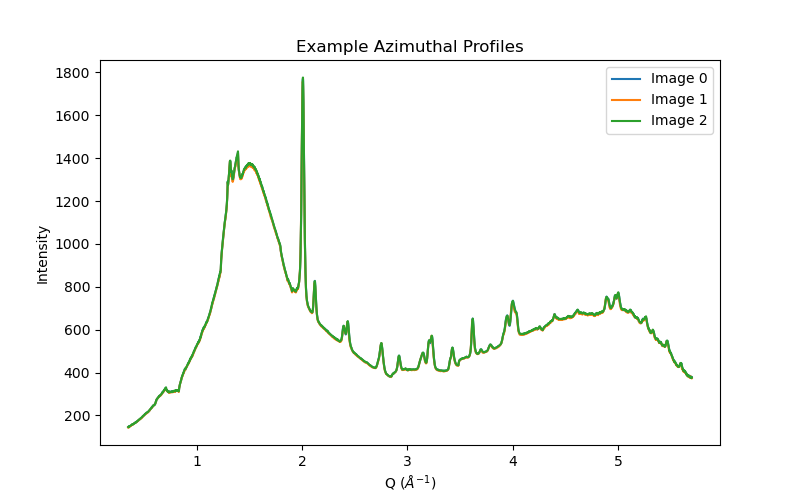

In [15]:
az_result = trxrd.azimuthal_average_pyfai(
    images=clean_dict["images"],
    centers=centers[0],
    npt=5000,
    unit="q_A^-1",
    radial_range=(0, 5.7),
    nan_radial_range=(0.35, 5.7),   # set Q < 0.3 to NaN
    azimuth_range=None,
    integration_mask=None,
    return_dict=True,
    progress_interval=100,
)

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)

plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, profiles[i], label=f"Image {i}")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Intensity")
plt.title("Example Azimuthal Profiles")
plt.legend()
plt.show()

## Load and Prepare Background Image(s)

In [9]:
# # Background path can be either:
# # - a single tif file
# # - or a folder containing many background tif files
# background_path = Path(r"C:\Users\lheald\Box\Sargent_Beamtime_Data\FTObackground\Monday13_0.5-deg_theta2.36samz00000_11978.tif")

# # Load Data
# bg_dict = trxrd.load_background(
#     background_path,
#     sort=True,
#     plot=True,
# )

# print(bg_dict.keys())
# print("Background stack shape:", bg_dict["background_stack"].shape)
# print("Background mean shape:", bg_dict["background_mean"].shape)

# # Apply mask to background stack
# bg_dict["background_stack"] = trxrd.apply_nan_mask(
#     bg_dict["background_stack"],
#     mask_path=mask_file,
#     plot=True,
#     image_index=0,
# )

# # bg_dict = trxrd.remove_xrays_pool(
# #     bg_dict["background_stack"],
# #     std_factor=STD_FACTOR,
# #     plot=True,
# #     image_index=0,
# #     return_dict=True,
# #     max_workers=MAX_PROCESSORS,
# #     progress_interval=100,
# # )


# bg_dict["background_mean"] = np.nanmean(bg_dict["background_stack"], axis=0)


# # Compute background azimuthal average
# bg_az_result = trxrd.compute_background_azimuthal_average(
#     background_input=bg_dict,
#     centers=np.nanmean(centers, axis=0),   # one average center in (x, y)
#     npt=5000,
#     radial_range=(0, 5),
#     nan_radial_range=(0.3, None),
#     plot=True,
#     return_dict=True,
# )

# q_bg = bg_az_result["radial"]
# background_profile = bg_az_result["background_profile_mean"]

## Subtract Scaled Background from Images

In [10]:
# bgsub_result = trxrd.subtract_scaled_background_profile(
#     radial=q,
#     profiles=profiles,
#     background_profile=background_profile,
#     norm_range=(4.0, 4.8),   # example region; adjust as needed
#     mode="mean",
#     scale_method="ratio",
#     plot=True,
#     plot_scale_factors=True,
#     plot_indices=[0, 10, 50],
#     return_dict=True,
# )

# profiles_bgsub = bgsub_result["corrected_profiles"]

# # Inspect Scaling Factors
# plt.figure(figsize=(8, 4))
# plt.plot(bgsub_result["scale_factors"])
# plt.xlabel("Image Index")
# plt.ylabel("Background Scale Factor")
# plt.title("Background Scale Factors")
# plt.show()

## Normalize Azimuthal Averages

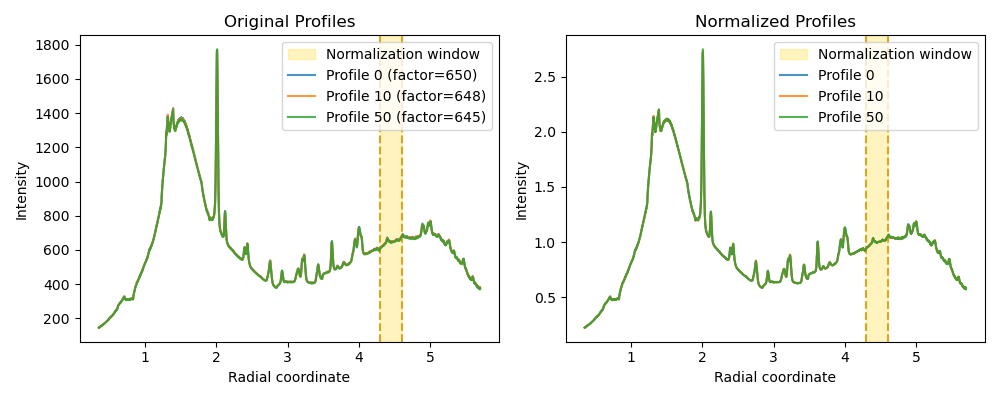

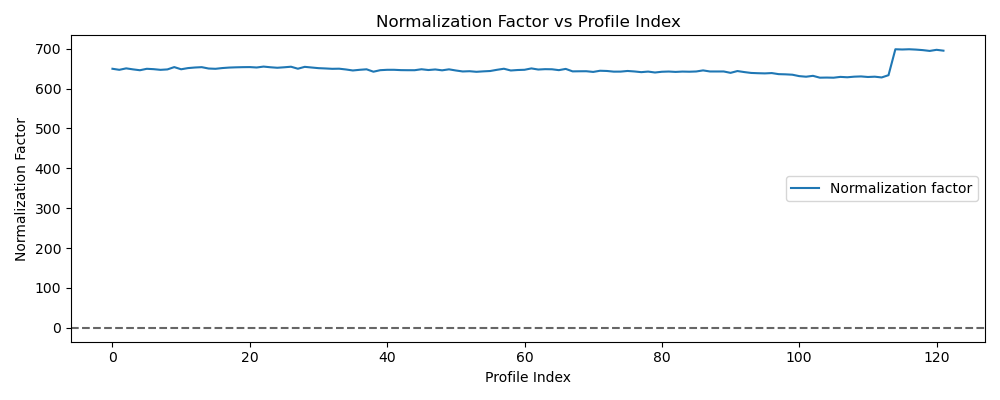

In [16]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(4.3, 4.6),   # example
    mode="mean",
    plot=True,
    plot_indices=[0, 10, 50],
    show_normalized_plot=True,
    return_dict=True,
    plot_factors=True,
)

profiles_norm = norm_result["normalized_profiles"]

## Subtract Baseline from Images

c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\scipy\sparse\_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


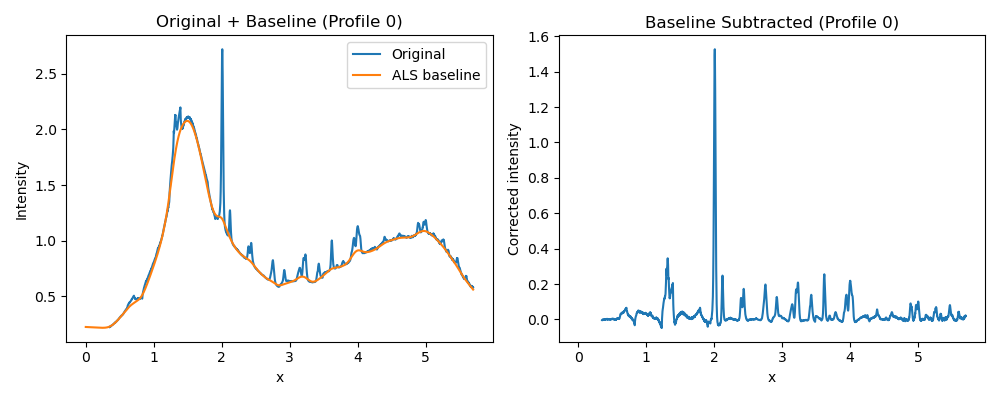

In [17]:
als_result = trxrd.subtract_als_baseline(
    data_array=profiles_norm,
    x_vals=q,
    lam=1e6,
    p=0.05,
    niter=10,
    plot=True,
    return_dict=True,
)

profiles_flat = als_result["corrected_data"]
baselines = als_result["baselines"]


## Make Reference Profile

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:3275: RuntimeWarning: Mean of empty slice
  reference_profile = np.nanmean(ref_group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


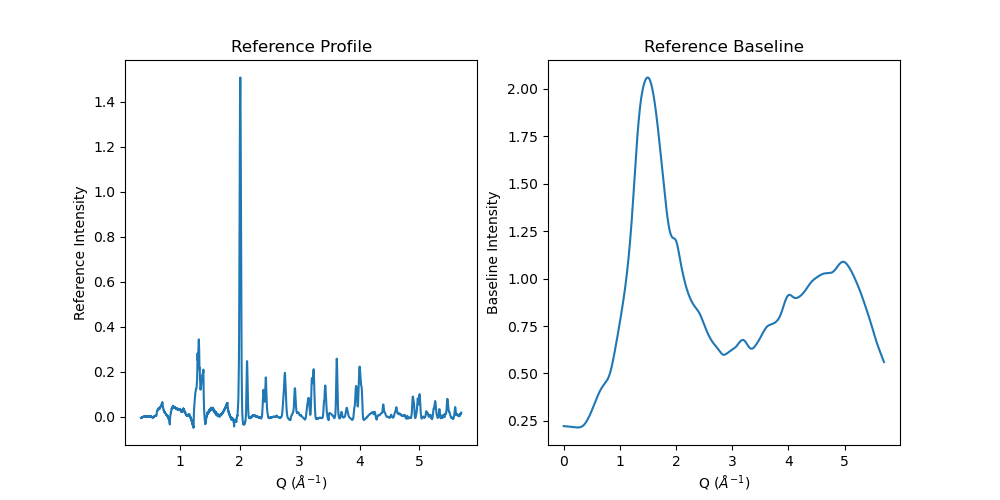

In [21]:
ref_result = trxrd.make_reference_profile(
    profiles=profiles_flat,
    delays=clean_dict["delay"],
    reference_selector=None,
    return_dict=True,
)

ref_baseline = trxrd.make_reference_profile(
    profiles=baselines,
    delays=clean_dict["delay"],
    reference_selector=None,
    return_dict=True,
)

reference_profile = ref_result["reference_profile"]
reference_baseline = ref_baseline["reference_profile"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q, reference_profile)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Reference Intensity")
plt.title("Reference Profile")

plt.subplot(1, 2, 2)
plt.plot(q, reference_baseline)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Baseline Intensity")
plt.title("Reference Baseline")

plt.show()

## Compute Difference Profiles

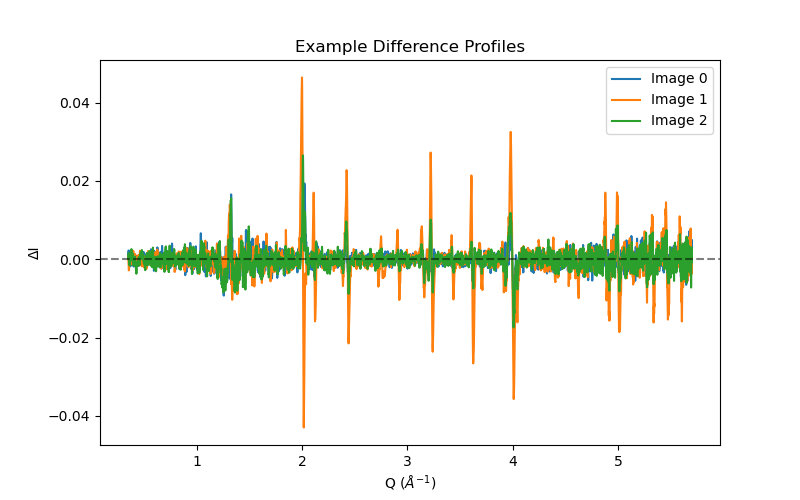

In [22]:
delta_result = trxrd.compute_delta_profiles(
    profiles=profiles_flat,
    reference_profile=reference_profile,
    mode="subtract",
    return_dict=True,
)

baseline_results = trxrd.compute_delta_profiles(
    profiles=baselines,
    reference_profile=reference_baseline,
    mode="subtract",
    return_dict=True,
)

delta_profiles = delta_result["delta_profiles"]
delta_baselines = baseline_results["delta_profiles"]


# Plot example difference profiles
plt.figure(figsize=(8, 5))
for i in [0, 1, 2]:
    plt.plot(q, delta_profiles[i], label=f"Image {i}")
plt.axhline(0, color="k", linestyle="--", alpha=0.5)
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("ΔI")
plt.title("Example Difference Profiles")
plt.legend()
plt.show()

## Average by Delay

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:3199: RuntimeWarning: Mean of empty slice
  mean_profiles[i] = np.nanmean(group, axis=0)
c:\Users\lheald\AppData\Local\miniconda3\envs\research\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


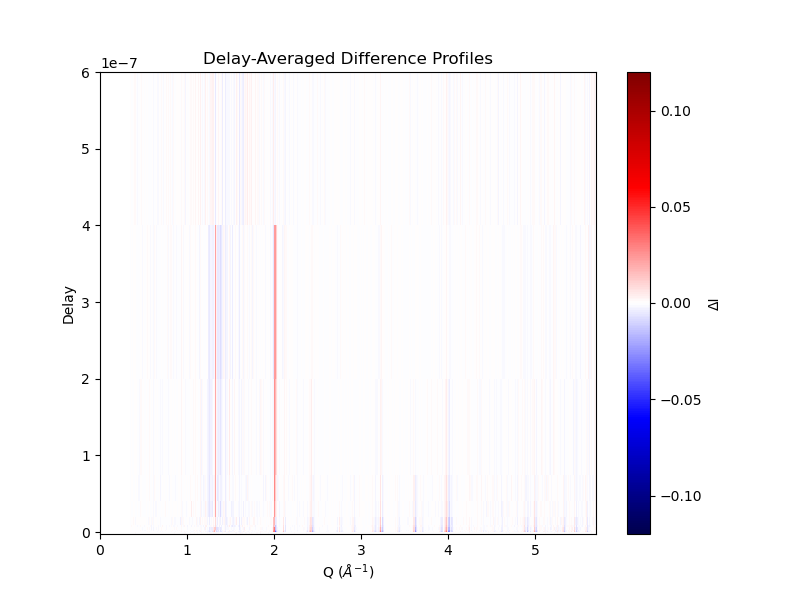

In [31]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_profiles,
    delays=clean_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_profiles = delay_result["mean_profiles"]
std_profiles = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_profiles, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-0.12, 0.12)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Plot Lineouts 

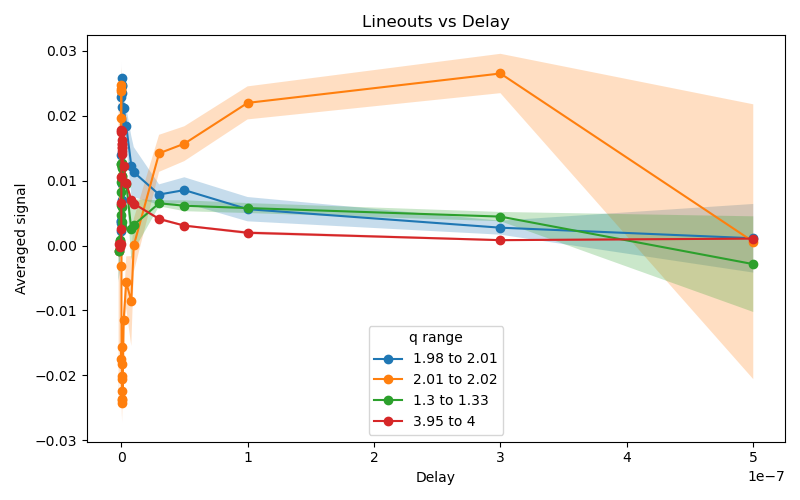

In [32]:
lineout_result = trxrd.lineouts_by_delay_from_per_image_profiles(
    radial=q,
    delta_profiles=delta_profiles,
    delays=clean_dict["delay"],
    q_ranges=[(1.98, 2.01), (2.01, 2.025), (1.3, 1.33), (3.95, 4.0)],
    average_mode="mean",
    error_type="sem",
    plot=True,
    return_dict=True,
)

## Check Baseline per Delay

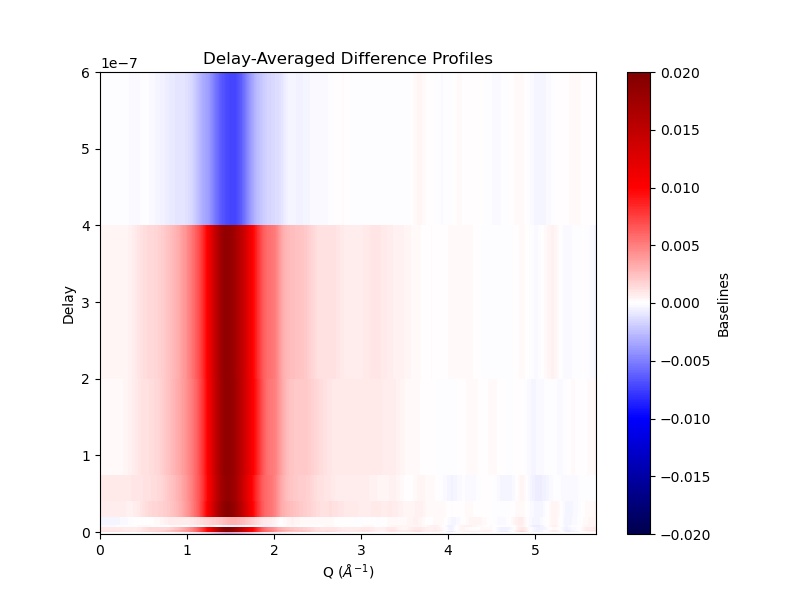

In [33]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_baselines,
    delays=clean_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_bkgs = delay_result["mean_profiles"]
std_bkgs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(q, unique_delays, mean_bkgs, shading="auto", cmap="seismic")
plt.colorbar(label="Baselines")
plt.clim(-0.02, 0.02)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Calculate f and f(2)

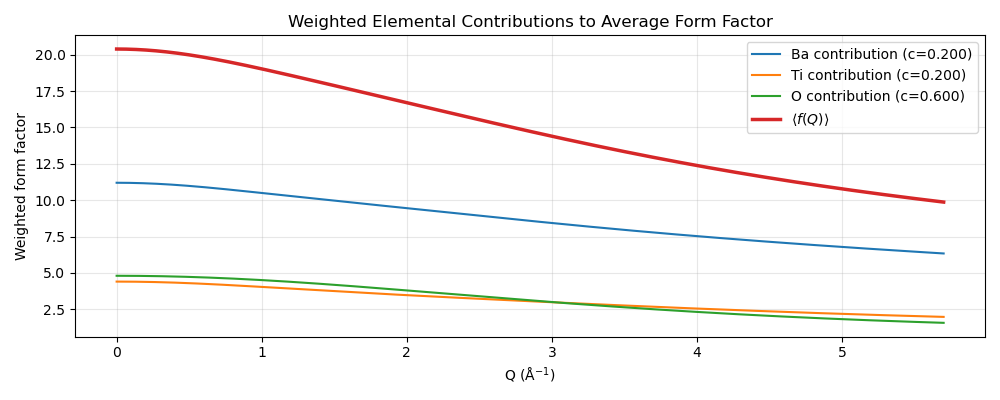

In [34]:
ff_results = trxrd.compute_average_form_factors(q, "BaTiO3", plot=True)

f_avg = ff_results["f_avg"]
f2_avg = ff_results["f2_avg"]


## Calculate S(Q) and F(Q)

In [35]:
# sq_result = trxrd.normalize_xray_scattering_to_sq_fq(
#     q=q,
#     iq=iq_total,
#     composition="BaTiO3",
#     mode="total",
#     plot=True,
#     return_dict=True,
# )

# sq = sq_result["sq"]
# fq = sq_result["fq"]

## Calculate dS(Q) and dF(Q)

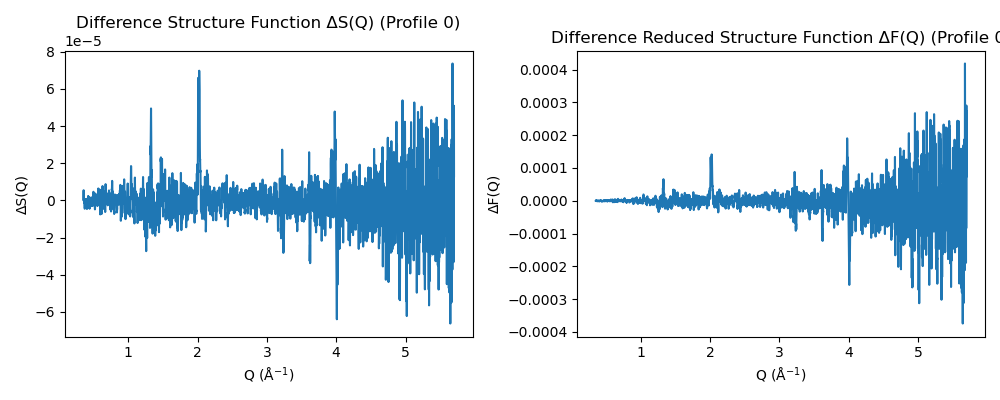

In [36]:
delta_result = trxrd.normalize_xray_scattering_to_sq_fq(
    q=q,
    iq=delta_profiles,
    composition="BaTiO3",
    mode="difference",
    plot=True,
    profile_index=0,
    return_dict=True,
)

delta_sq = delta_result["delta_sq"]
delta_fq = delta_result["delta_fq"]

## Calculate dG(r)

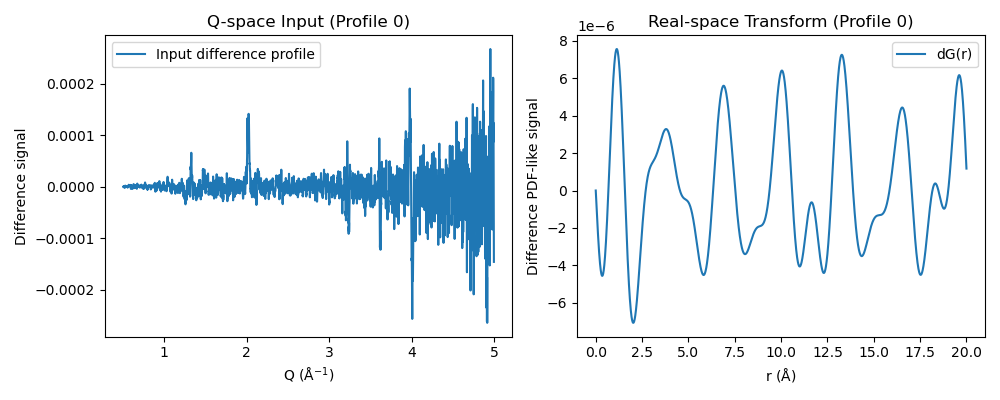

(122, 2000)


In [37]:
dGr_result = trxrd.compute_difference_pdf(
    q=q,
    delta_iq=delta_result["delta_fq"],
    r_max=20,
    n_r=2000,
    q_range=(0.5, 5.0),
    window="lorch",
    plot=True,
    profile_index=0,
    return_dict=True,
)

r = dGr_result["r"]
dGr_profiles = dGr_result["dgr"]
print(dGr_profiles.shape)   # should be (n_profiles, n_r)

## Plot Delay Averaged dG(r)

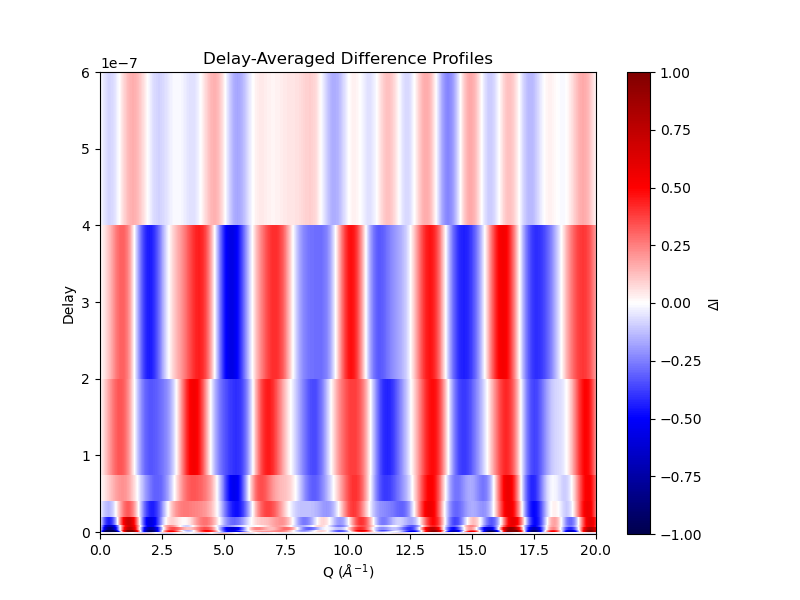

In [40]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=dGr_profiles,
    delays=clean_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_dgrs = delay_result["mean_profiles"]
std_dgrs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, mean_dgrs*1e5, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-1, 1)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()

## Compare Results

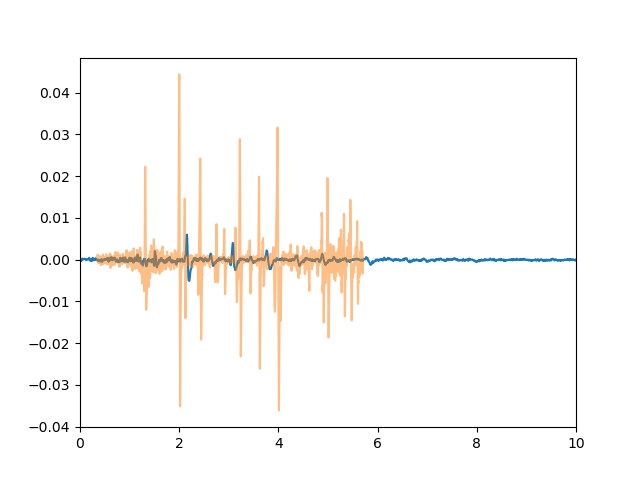

In [46]:
df = pd.read_excel("C:\\Users\\lheald\\Documents\\Guzelturk_Lab\\TRXRDPython\\testdata\\output\\BaTiO3_data_CottsExp_Nov25.xlsx", header=2)

plt.figure()
# plt.plot(df["Q"], df["deltaI(Q,-5ns)"])
plt.plot(df["Q"], df["deltaI(Q,0.6ns)"])
# plt.plot(q, mean_profiles[1])
plt.plot(q, mean_profiles[11], alpha=0.5)
plt.xlim(0,10)
plt.show()

In [42]:
unique_delays

array([-2.00e-09, -1.00e-09,  5.00e-11,  1.00e-10,  1.25e-10,  1.50e-10,
        2.00e-10,  2.50e-10,  3.00e-10,  4.00e-10,  5.00e-10,  6.00e-10,
        7.00e-10,  8.00e-10,  9.00e-10,  1.00e-09,  2.00e-09,  4.00e-09,
        8.00e-09,  1.00e-08,  3.00e-08,  5.00e-08,  1.00e-07,  3.00e-07,
        5.00e-07])

## Save Results

In [ ]:
# np.savez(
#     "trxrd_processed_results.npz",
#     q=q,
#     delays=clean_dict["delay"],
#     image_numbers=clean_dict["image_number"],
#     centers=centers,
#     profiles=profiles,
#     profiles_bgsub=profiles_bgsub,
#     profiles_norm=profiles_norm,
#     reference_profile=reference_profile,
#     delta_profiles=delta_profiles,
#     unique_delays=unique_delays,
#     mean_profiles=mean_profiles,
#     std_profiles=std_profiles,
# )

: 

## Calculate Qualitative dPDF

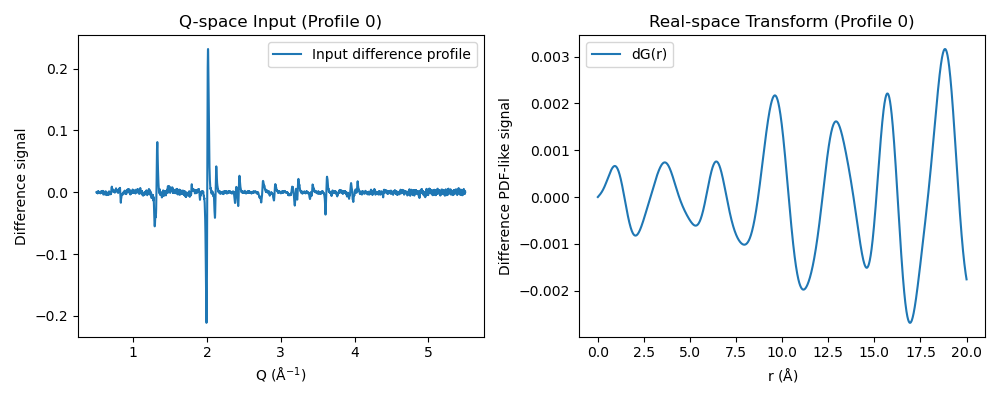

(122, 2000)


In [ ]:
dgr_result = trxrd.compute_difference_pdf(
    q=q,
    delta_iq=delta_profiles,
    r_max=20,
    n_r=2000,
    q_range=(0.5, 5.5),
    window="lorch",
    plot=True,
    profile_index=0,
    return_dict=True,
)

r = dgr_result["r"]
dgr_profiles = dgr_result["dgr"]
print(dgr_profiles.shape)   # should be (n_profiles, n_r)

## Plot Qualitative dPDF by Delay (no form factors)

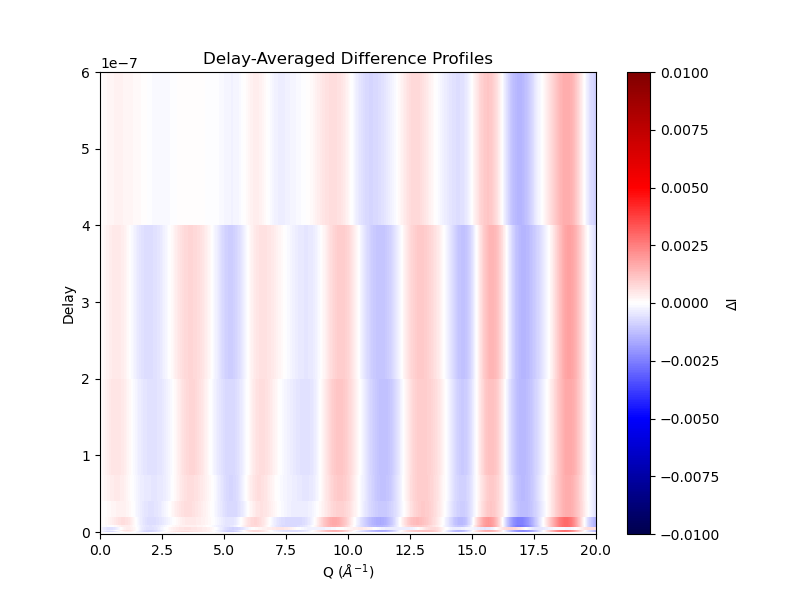

In [ ]:
delay_result = trxrd.average_profiles_by_delay(
    profiles=dgr_profiles,
    delays=clean_dict["delay"],
    unique_delays=None,
    return_dict=True,
)

unique_delays = delay_result["unique_delays"]
mean_dgrs = delay_result["mean_profiles"]
std_dgrs = delay_result["std_profiles"]

# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(8, 6))
plt.pcolormesh(r, unique_delays, mean_dgrs, shading="auto", cmap="seismic")
plt.colorbar(label="ΔI")
plt.clim(-0.01, 0.01)  # set color limits for better contrast; adjust as needed
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.show()